# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
# I'm attempting to work on my own machine through VSCode.

import os
import subprocess
import sys

repo_path = os.path.expanduser("~butterflai") # Copilot helped me with this -- it was throwing an error because the path didn't exist.
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /Users/pplanet/butterflAI/butterflai/weeks/week_01/~butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : mps
   Seed     : 42


{'in_colab': False,
 'device': device(type='mps'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/var/folders/08/_3bxr1rj60bbzl2t7hgyzv1h0000gn/T/ipykernel_16519/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/var/folders/08/_3bxr1rj60bbzl2t7hgyzv1h0000gn/T/ipykernel_16519/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


*Note: The above failed to run at first because I had pandas 3.0.1 installed. I checked Colab, and it uses 2.2.2 -- presumably, this is the version that the rest of the notebook uses (and the other notebooks will use), so I changed the environment file to specify this requirement.*

## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

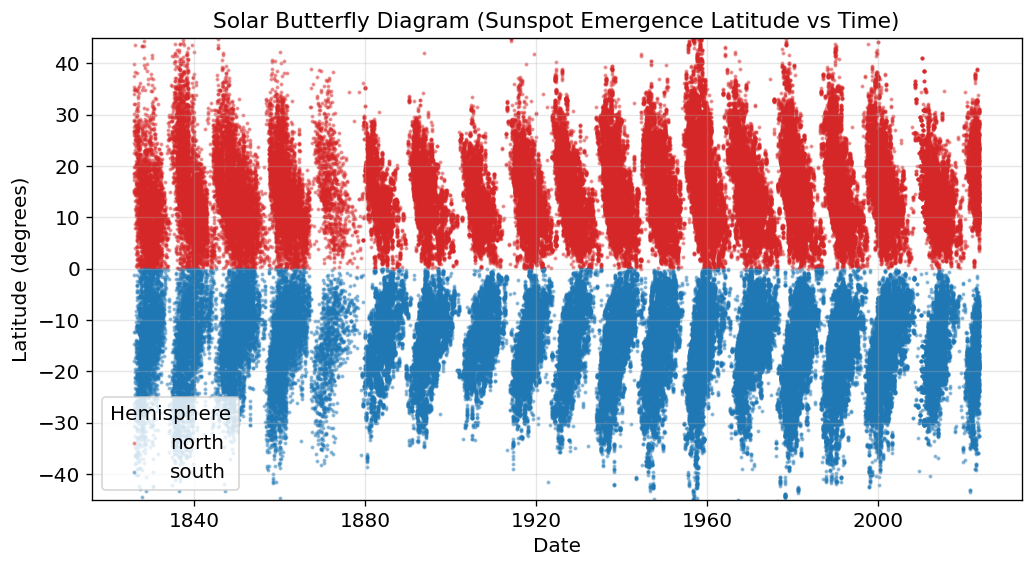

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


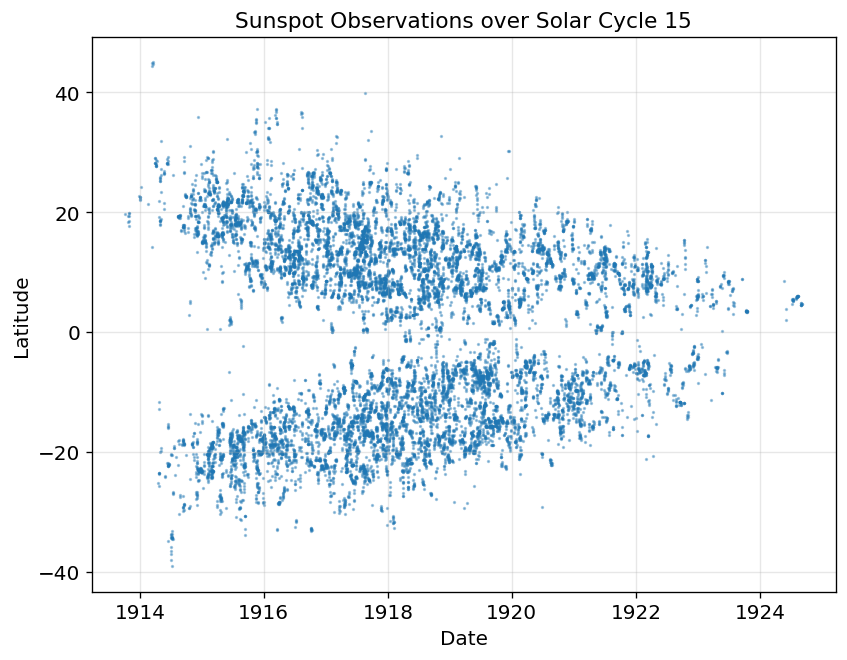

In [122]:
# Your code here: Visualize a single solar cycle
solar_cycle_id = 15

fig, ax = plt.subplots(figsize=(8, 6))

df_onecycle = df.loc[df['CYCLE'] == solar_cycle_id]
ax.scatter(df_onecycle["date"], df_onecycle["latitude"], s=1, alpha=0.4)

ax.set_title(f"Sunspot Observations over Solar Cycle {solar_cycle_id}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude")

plt.show()

*I can see the butterfly! I also see these weird spots where there aren't any sunspots for a couple months at a certain latitude, even if there are a few at higher and lower latitudes. What's with that? I'm going to ask Copilot, and check its answer with the Discord.*

*...Copilot's answer was entirely unhelpful.*

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


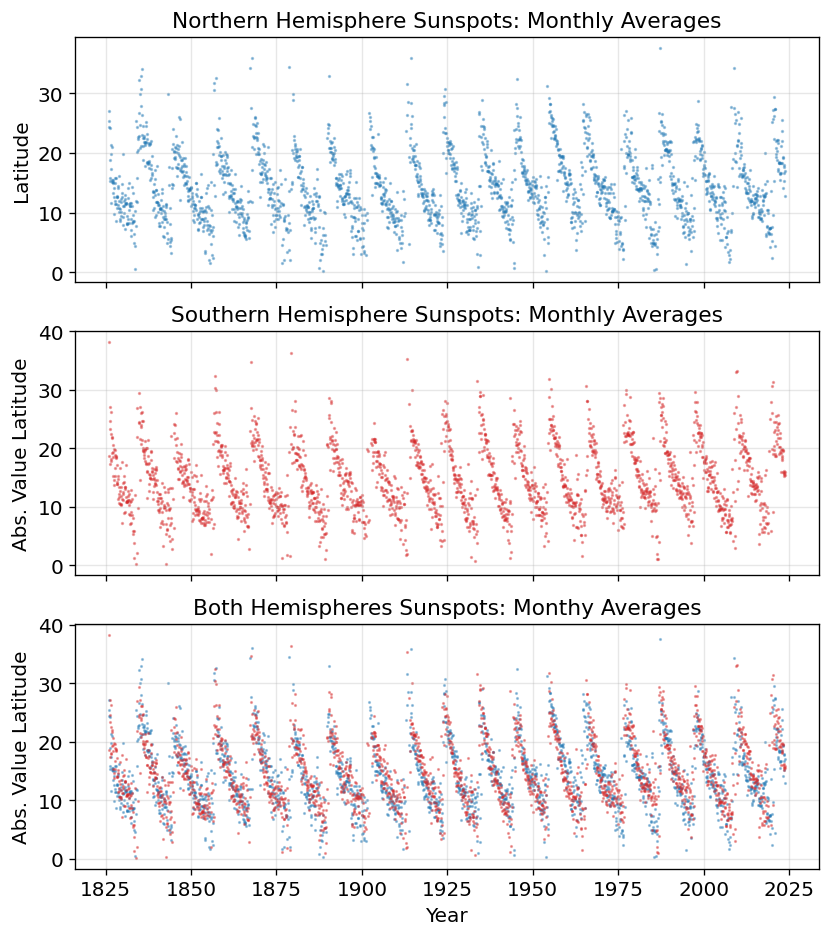

In [ ]:
# Your code here: Calculate and plot mean latitudinal paths
import numpy as np

df["year"] = df["date"].apply(lambda v: (v.year + (v.month / 12.)))

month_latitude_s = np.array([(year[0], group["latitude"].mean()) for year, group in df.loc[df["hemisphere"] == 'south'].groupby(["year"])])

month_latitude_n = np.array([(year[0], group["latitude"].mean()) for year, group in df.loc[df["hemisphere"] == 'north'].groupby(["year"])])

fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, figsize=(8, 9))

ax1.scatter(month_latitude_n[:,0], month_latitude_n[:,1], s=1, alpha=0.4, c='tab:blue')
ax2.scatter(month_latitude_s[:,0], np.abs(month_latitude_s[:,1]), s=1, alpha=0.4, c='tab:red')
ax3.scatter(month_latitude_n[:,0], month_latitude_n[:,1], s=0.8, alpha=0.4, c='tab:blue')
ax3.scatter(month_latitude_s[:,0], np.abs(month_latitude_s[:,1]), s=0.8, alpha=0.4, c='tab:red')

ax1.set_ylabel("Latitude")
ax2.set_ylabel("Abs. Value Latitude")
ax3.set_ylabel("Abs. Value Latitude")

ax3.set_xlabel("Year")
ax1.set_title("Northern Hemisphere Sunspots: Monthly Averages")
ax2.set_title("Southern Hemisphere Sunspots: Monthly Averages")
ax3.set_title("Both Hemispheres Sunspots: Monthy Averages")

plt.show()

*Discussion: Seeing the monthly averages makes it more clear that the general trend during a solar cycle is for sunspots to emerge closer to the solar equator later in the cycle. I plotted both hemispheres together to make it clear that this happens in sync on both sides of the Sun; at any given time, the average latitude of sunspots in the Southern hemisphere is approximately opposite the average latitude of the sunspots in the Northern hemisphere.*

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*

*I will include all of my conversation with Copilot at the bottom of this notebook. Its response includes what I already believed were good prompting techniques--it describes specificity, context, explanations and examples, and iteration as important for prompting.*

*Frankly, I am hesitant about the use of generative AI in my day-to-day life and work. It is a very powerful tool, and I am in no doubt that, for better or worse, it will be deeply embedded in every area of life within a few decades. I feel that the learning curve for using AI effectively is less strong than the learning curve for the skills that AI will be unable to substitute for-it seems to me that there is and will continue to be a low cap for the skill necessary to use AI, and I need to spend my time as a student focusing more on the skills that will distinguish me compared to my peers when we all have access to and the same skills with AI.*

*Even so, in the interest of preparation for a rapidly approaching future, I have used, and will continue to use, Copilot for the ButterflAI project. I think it did well here, helping me when I was stuck with setting up this notebook on my local machine, though I think it may have inadvertantly copied the entire repository into the notebook folder. When I asked it a physics question, about my plots, it did not give me any new information. I will have to figure out better techniques for those kinds of questions.*

*I think I will continue to ask it to help me to explain code I am stuck on. I will at no point ask it to write code for me that I have not already attempted on my own, as I feel it is an important skill to be able to pair my own knowledge with AI, and I cannot do that if I cannot theoretically do the work without the assistance of AI. I am not sold on its ability to help with understanding physical concepts, besides to reframe a concept to which I have already been introduced, because my abilities to factcheck it are limited.*


### Conversation with Copilot

*Can you help me understand why this cell is failing? What file system is read-only?* [Cell 3]

You have exceeded your premium request allowance. We have automatically switched you to GPT-4.1 which is included with your plan. [Enable additional paid premium requests](command:chat.enablePremiumOverages) to continue using premium models.Your setup cell is using the path `/content/butterflai`, which is the default working directory for Google Colab. On your Mac, this directory does not exist, and you likely do not have write permissions to `/content` (which is not a standard directory on macOS). This is causing the cell to fail because it tries to clone the repo into a non-existent or read-only location.

**On your Mac, the root `/content` directory is not writable (or doesn't exist), so the file system appears "read-only" for this path.**

**How to fix:**  
Change `repo_path` to a directory you own, such as your project folder. For example:



In [ ]:
repo_path = os.path.expanduser("~/butterflai")



This will clone the repo into your home directory, which is writable on your Mac.

*On the output of this cell, there are dots on the "wings" of the butterfly -- spaces where there are no sunspots for a length of time, even when there are sunspots present at higher and lower latitude. Is this a consequence of a physical phenomenon, or is it more of a product of the way this data is being collected and displayed?* [Cell 12]

Great observation! The "gaps" or empty spaces you see in the butterfly diagram—where there are no sunspots at certain latitudes for stretches of time—can be due to a combination of both physical and data-related factors:

**1. Physical Phenomena:**  
- Sunspots do not appear uniformly at all latitudes at all times. During a solar cycle, sunspots tend to emerge at mid-latitudes and then migrate toward the equator as the cycle progresses. There are periods and latitudes where sunspot emergence is naturally rare or absent.
- Some cycles may have weaker activity, leading to fewer sunspots overall, which can accentuate these gaps.

**2. Data Collection and Display:**  
- The catalog only records days when sunspots are observed. If there are no sunspots at a particular latitude on a given day, that latitude simply isn't represented in the data for that day.
- Observational gaps (e.g., due to weather, instrument downtime, or historical limitations) can also create artificial gaps in the plot.
- The scatter plot only shows actual observations; it does not interpolate or fill in missing data, so any absence of data at a latitude/time appears as a gap.

**Summary:**  
Most of the "wings" shape is a real solar cycle effect, but the gaps within the wings are likely a mix of real physical absence of sunspots at those latitudes/times and the way the data is recorded (i.e., only showing where sunspots were actually observed, with no interpolation).

If you want to distinguish between these causes, you could:
- Check for periods of missing data in the catalog.
- Aggregate or smooth the data (e.g., bin by month and latitude) to see if the gaps persist.
- Compare with other sunspot catalogs for consistency.

Let me know if you'd like code to help investigate this!

*What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?*

The best way to prompt an AI assistant for learning machine learning and solar physics concepts effectively is to:

1. **Be specific about your goal:**  
   Clearly state what you want to learn or accomplish (e.g., "Explain how random forests work for classification," or "Help me understand the solar dynamo theory").

2. **Provide context:**  
   Share relevant code, data, or background information so the AI can tailor its response to your situation.

3. **Ask for explanations at your level:**  
   Indicate your current understanding (beginner, intermediate, advanced) and request explanations, analogies, or step-by-step breakdowns.

4. **Request examples or visualizations:**  
   Ask for code snippets, diagrams, or real-world analogies to make abstract concepts more concrete.

5. **Iterate and clarify:**  
   If the first answer isn’t clear, ask follow-up questions or request the information in a different format (e.g., "Can you explain that with a plot?" or "Can you summarize in three bullet points?").

6. **Encourage best practices:**  
   Ask for tips on common pitfalls, recommended resources, or how to validate your understanding.

**Example prompt:**  
*"I'm new to solar physics. Can you explain how sunspot cycles relate to the solar magnetic field, using simple language and a diagram? Also, how could I model this pattern with Python?"*

Applying these strategies will help you get more targeted, useful, and understandable responses from AI assistants as you learn.

### One more thing

*A couple columns in the dataframe pertain to the size of the sunspots. I want to see if I can see a pattern over the solar cycles in that too*

In [123]:
df

,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,hemisphere,year_month,year
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.000,570.0000,101.0,NaN,1.0,south,"(1825, 11)",1825.916667
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.000,190.0000,102.0,NaN,1.0,south,"(1825, 11)",1825.916667
4,1825-11-09,14.0,45.0,0.0,-14.6,320.7,500.000,150.0000,102.0,NaN,1.0,south,"(1825, 11)",1825.916667
5,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.000,150.0000,103.0,NaN,1.0,south,"(1825, 11)",1825.916667
6,1825-11-11,12.0,0.0,0.0,-26.3,320.8,470.000,140.0000,103.0,NaN,1.0,south,"(1825, 11)",1825.916667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314643,2023-10-16,4.0,19.2,0.0,8.3,210.9,54.072,4.3123,325000.0,25.0,1002.0,north,"(2023, 10)",2023.833333
314644,2023-10-16,4.0,19.2,0.0,11.0,146.1,373.360,8.5110,325000.0,25.0,1002.0,north,"(2023, 10)",2023.833333
314645,2023-10-16,4.0,19.2,0.0,12.9,109.6,18.024,2.6868,325000.0,25.0,1002.0,north,"(2023, 10)",2023.833333
314646,2023-10-16,4.0,19.2,0.0,4.5,91.9,12.243,3.2207,325000.0,25.0,1002.0,north,"(2023, 10)",2023.833333


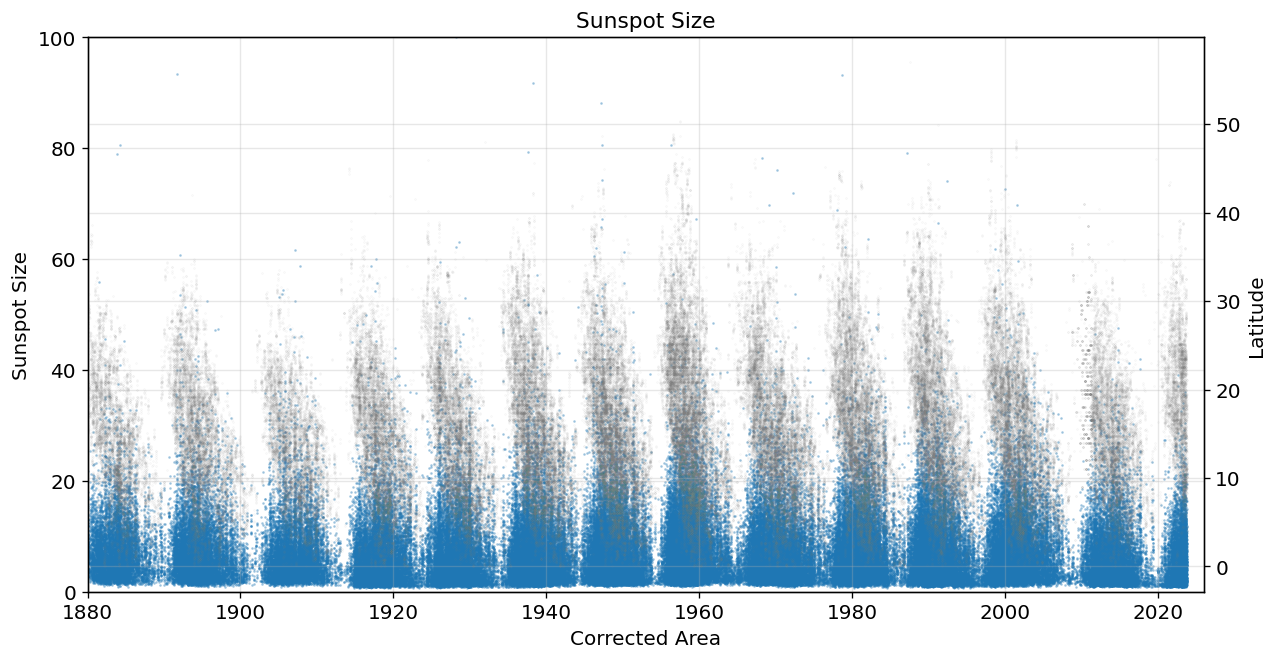

In [148]:
import datetime as dt

fig, ax = plt.subplots(figsize=(12,6))
ax1 = ax.twinx()

ax1.scatter(df["date"], df["latitude"].abs(), s=0.1, c='grey', alpha=0.1) # to see the relative place in the solar cycle
ax.scatter(df["date"], df["CAUnc"], s=0.3, alpha=0.4)

ax.set_title(f"Sunspot Size")
ax.set_xlabel("Corrected Area")
ax.set_ylabel("Sunspot Size")
ax1.set_ylabel("Latitude")

ax.set_xlim(dt.date(1880,1,1), dt.date(2026,1,1)) # something weird is happening with the corrected area values before this. I would need more context for this data to comment
ax.set_ylim(0,100)

plt.show()

*It looks like sunspot sizes peak in the middle of the solar cycle. This checks out with my understanding of the solar cycle. I'd like to play more with this in the future!*

*Ideas for when I have time:*
* *Rather than plotting individual sunspot sizes, take a monthly average or a rolling sum of sunspot sizes as a metric of total sunspot area on the Sun.*
* *Plot latitude vs size! My guess is that the high-latitude sunspots are small, and the low-latitude sunspots are small, but the ones right in the middle, around maybe 15 degrees, tend to get larger. Maybe there will be some more patterns that emerge from that as well.*
* *Sum size and latitude over each solar cycle, plot all three: Time, average (or total!) sunspot area, latitude. I think I see a wider pattern here: the latitude peaks in different solar cycles grow and shrink over time with a about a 120-year period, and the areas correspondingly grow and shrink (this does assume the data is reliable). I think it'd be an interesting thing to look at.*
* *More precisely define the functions that the butterfly curves follow: For each solar cycle, in each hemisphere, solve for a linear or quadratic best fit for the latitude. I'd also be curious to see this along the top edge and bottom edge of the wings, too. Is there a general form that describes the distribution of sunspots over time? It seems to me that the shape of the curve is more pronounced on the side closer to the solar equator, and more of a straight line on the far edge of the wing. Can that be described mathematically, and does it lead to a more precise way of describing long-term swings in the strength of the solar cycle than the above?*